# **Taller 05: Clustering DBScan**

**Inteligencia Artificial ELP 8012 - Universidad del Norte - Profesor: Eduardo Zurek, PH.D.**

**Grupo:** Paula Núñez, Isabella Arrieta y Natalia Carpintero

Diseñe e implemente un algoritmo de clustering DBScan que reciba como entrada un conjunto de datos sintéticos en dos dimensiones generados a partir de una figura que contenga grupos amorfos.

En este notebook se usa la imagen base de la carpeta IMG/our_image.png, se generan puntos 2D a partir de sus regiones amorfas, se agregan outliers uniformes y se aplica DBSCAN con análisis exploratorio de k-distancia y evaluación del desempeño.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from scipy import ndimage
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


Imagen base: C:\Users\NATALIA\Documents\Clases Universidad\IA\Taller-05-Clustering-DBScan\IMG\profe_image.png
Dimensiones de la imagen: 694 x 380
Número de regiones detectadas: 40
Puntos de señal generados: 4117 (min/máx por región: 20/400)


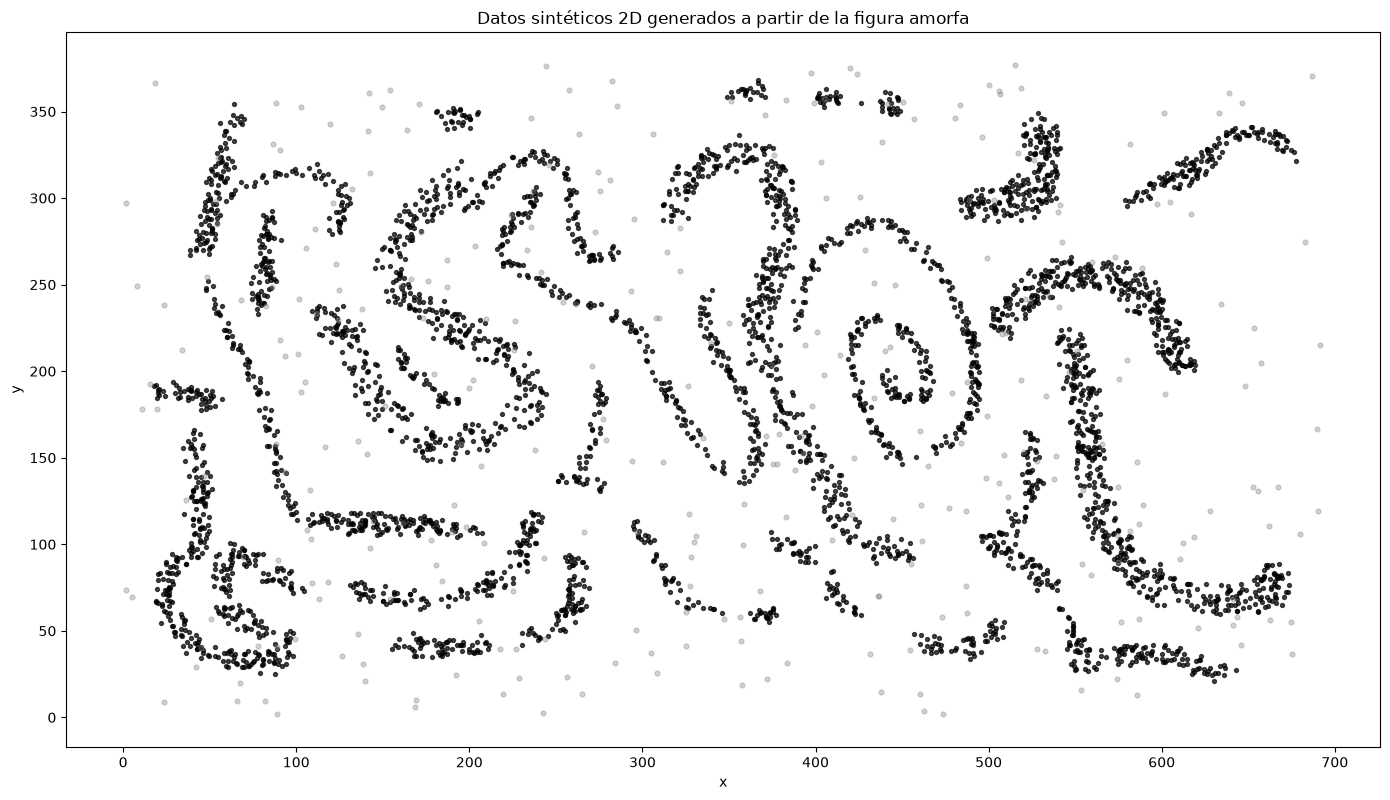

,x,y
0,556.463303,32.811237
1,614.360248,31.073424
2,546.610190,57.623314
3,550.635151,27.777777
4,593.529194,35.984421


In [7]:
plt.style.use("default")

IMG_PATH = Path("IMG/profe_image.png")
print(f"Imagen base: {IMG_PATH.resolve()}")
img = np.array(Image.open(IMG_PATH).convert("L"))
img = np.flipud(img)
print(f"Dimensiones de la imagen: {img.shape[1]} x {img.shape[0]}")

# Convertimos la imagen en una máscara binaria: fondo blanco, grupos negros.
mask = img < 200
labeled, n_regions = ndimage.label(mask)

# Se filtran regiones muy pequeñas para descartar ruido y mantener grupos amorfos.
min_region_size = 80
valid_regions = []
for region_id in range(1, n_regions + 1):
    ys, xs = np.where(labeled == region_id)
    if len(xs) >= min_region_size:
        valid_regions.append(np.column_stack([xs.astype(float), ys.astype(float)]))

print(f"Número de regiones detectadas: {len(valid_regions)}")

# --- MUESTREO PROPORCIONAL A LA DENSIDAD ---
# Antes se tomaba un máximo fijo de 90 puntos por región, sin importar su tamaño.
# Como las regiones (trazos largos y delgados vs. manchas compactas) varían mucho
# en área, un tope fijo deja algunas regiones MUY dispersas (pocos puntos en un
# trazo largo -> huecos grandes entre puntos) y otras MUY densas. Con un único eps
# global, esto rompe la conectividad de DBSCAN en las regiones dispersas y fragmenta
# cada trazo en muchos mini-clústeres o lo manda casi entero a ruido.
# En su lugar, muestreamos una fracción del área de cada región para mantener una
# densidad de puntos (puntos por píxel²) aproximadamente uniforme entre regiones.
rng = np.random.default_rng(42)
sample_fraction = 0.12   # fracción de píxeles de cada región que se conserva
min_pts_region = 20      # piso para que ninguna región quede subrepresentada
max_pts_region = 400     # techo para no saturar regiones enormes

cluster_samples = []
for region_points in valid_regions:
    n_avail = len(region_points)
    n_points = int(np.clip(n_avail * sample_fraction, min_pts_region, max_pts_region))
    n_points = min(n_points, n_avail)
    idx = rng.choice(n_avail, size=n_points, replace=False)
    sampled = region_points[idx]
    jitter = rng.normal(0, 1.0, size=sampled.shape)
    cluster_samples.append(sampled + jitter)

n_signal_points = sum(len(c) for c in cluster_samples)
print(f"Puntos de señal generados: {n_signal_points} "
      f"(min/máx por región: {min(len(c) for c in cluster_samples)}/"
      f"{max(len(c) for c in cluster_samples)})")

# Se agregan outliers uniformes en el espacio 2D, proporcionales al tamaño del
# dataset (antes era un número fijo de 120, que podía quedar sub- o sobre-
# representado según cuántos puntos de señal se generen).
width, height = img.shape[1], img.shape[0]
outlier_fraction = 0.08
n_outliers = int(outlier_fraction * n_signal_points)
outliers = rng.uniform([0, 0], [width, height], size=(n_outliers, 2))

X = np.vstack(cluster_samples + [outliers])
true_cluster_ids = []
for i in range(len(cluster_samples)):
    true_cluster_ids.append(np.full(len(cluster_samples[i]), i))
true_labels = np.concatenate(true_cluster_ids + [np.full(len(outliers), -1)])

# Visualización de los grupos amorfos generados a partir de la imagen.
fig, ax = plt.subplots(figsize=(14, 8))
for pts in cluster_samples:
    ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.7, c="black")
ax.scatter(outliers[:, 0], outliers[:, 1], s=12, c="gray", alpha=0.35)
ax.set_title("Datos sintéticos 2D generados a partir de la figura amorfa")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

X_df = pd.DataFrame(X, columns=["x", "y"])
X_df.head()


Índice del punto de inflexión: 4122
Estimación inicial de epsilon (k=6): 8.457


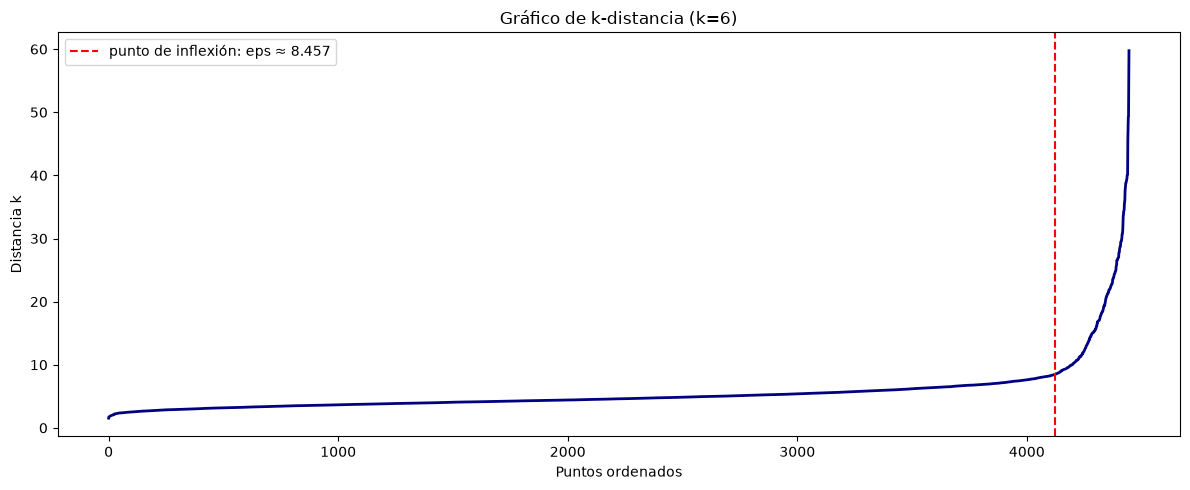

Mejor configuración encontrada (silueta, con guardas de ruido/clústeres):
{'min_pts': 10.0, 'eps': 7.611558919422411, 'n_clusters': 82.0, 'noise_ratio': 0.12348178137651822, 'silhouette': 0.37436458123959654, 'davies_bouldin': 0.596865673306497, 'calinski_harabasz': 3357.35144979955}
Parámetros recomendados: eps = 7.612, MinPts = 10


In [8]:
# Análisis exploratorio con gráficos de k-distancia para estimar eps y MinPts.

def knee_point(values):
    """Punto de máxima curvatura de una curva creciente: el punto con mayor
    distancia perpendicular a la recta que une su primer y último valor
    (versión simplificada del método 'kneedle', más robusta ante ruido que
    mirar la segunda diferencia punto a punto)."""
    n = len(values)
    if n < 4:
        return 0, values[0]
    x = np.arange(n)
    p1 = np.array([x[0], values[0]])
    p2 = np.array([x[-1], values[-1]])
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
    pts = np.column_stack([x, values]) - p1
    proj_len = pts @ line_vec_norm
    perp = pts - np.outer(proj_len, line_vec_norm)
    dist = np.linalg.norm(perp, axis=1)
    idx = int(np.argmax(dist))
    return idx, values[idx]

# Se usa k = 6 (≈ MinPts de referencia) para el gráfico de k-distancia.
k_ref = 6
knn = NearestNeighbors(n_neighbors=k_ref)
knn.fit(X)
dists, _ = knn.kneighbors(X)
k_dist = np.sort(dists[:, -1])

idx_rodilla, eps_approx = knee_point(k_dist)
print(f"Índice del punto de inflexión: {idx_rodilla}")
print(f"Estimación inicial de epsilon (k={k_ref}): {eps_approx:.3f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(np.arange(len(k_dist)), k_dist, linewidth=2, color="navy")
ax.axvline(idx_rodilla, color="red", linestyle="--", linewidth=1.5,
           label=f"punto de inflexión: eps ≈ {eps_approx:.3f}")
ax.set_title(f"Gráfico de k-distancia (k={k_ref})")
ax.set_xlabel("Puntos ordenados")
ax.set_ylabel("Distancia k")
ax.legend()
plt.tight_layout()
plt.show()

# --- BÚSQUEDA DE PARÁMETROS ALREDEDOR DE LA ESTIMACIÓN DEL CODO ---
# Antes se buscaba en un rango fijo (eps entre 3 y 15) elegido a ciegas, y se
# escogía la configuración con mayor silueta sin ninguna otra restricción.
# Eso favorece sistemáticamente valores de eps pequeños que generan muchos
# mini-clústeres compactos con muy poca dispersión interna (silueta alta)
# pero que mandan la mayoría de los puntos a ruido -- es "hacer trampa" a la
# métrica, no una buena segmentación de las figuras amorfas.
# Ahora el rango de búsqueda se centra en la estimación del codo (más
# confiable que un rango arbitrario) y se descartan configuraciones que:
#   1) generen menos de 2 clústeres,
#   2) dejen muy pocos puntos válidos para evaluar,
#   3) manden más del 35% de los puntos a ruido (fragmentación/pérdida
#      excesiva de señal real).
# Importante: se explora SOLO desde el codo hacia arriba (0.9x a 2.2x el eps
# del codo), no hacia abajo. Bajar el eps por debajo del codo es justamente lo
# que rompe la conectividad dentro de cada trazo y produce fragmentación; el
# codo marca el eps mínimo razonable para que un trazo se mantenga conectado.
eps_candidates = np.linspace(eps_approx * 0.9, eps_approx * 2.2, 15)
min_pts_candidates = [4, 6, 8, 10, 12]
max_noise_ratio = 0.20
parameter_scan = []

for min_pts in min_pts_candidates:
    for eps in eps_candidates:
        labels = DBSCAN(eps=eps, min_samples=min_pts).fit_predict(X)
        unique_labels = np.unique(labels)
        n_clusters = len(unique_labels[unique_labels != -1])
        noise_ratio = (labels == -1).mean()

        if n_clusters < 2:
            continue
        if noise_ratio > max_noise_ratio:
            continue

        valid = labels != -1
        valid_labels = labels[valid]
        if valid.sum() < 10 or len(np.unique(valid_labels)) < 2:
            continue  # silhouette/DB requieren al menos 2 clústeres con puntos

        sil = silhouette_score(X[valid], valid_labels)
        db = davies_bouldin_score(X[valid], valid_labels)
        ch = calinski_harabasz_score(X[valid], valid_labels)

        parameter_scan.append({
            "min_pts": min_pts,
            "eps": eps,
            "n_clusters": n_clusters,
            "noise_ratio": noise_ratio,
            "silhouette": sil,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
        })

scan_df = pd.DataFrame(parameter_scan)
if not scan_df.empty:
    best = scan_df.sort_values("silhouette", ascending=False).iloc[0]
    print("Mejor configuración encontrada (silueta, con guardas de ruido/clústeres):")
    print(best.to_dict())
    best_eps = float(best["eps"])
    best_min_pts = int(best["min_pts"])
else:
    best_eps = float(eps_approx)
    best_min_pts = 8
    print("No se encontró una búsqueda válida; se usa la estimación inicial de eps y MinPts.")

print(f"Parámetros recomendados: eps = {best_eps:.3f}, MinPts = {best_min_pts}")


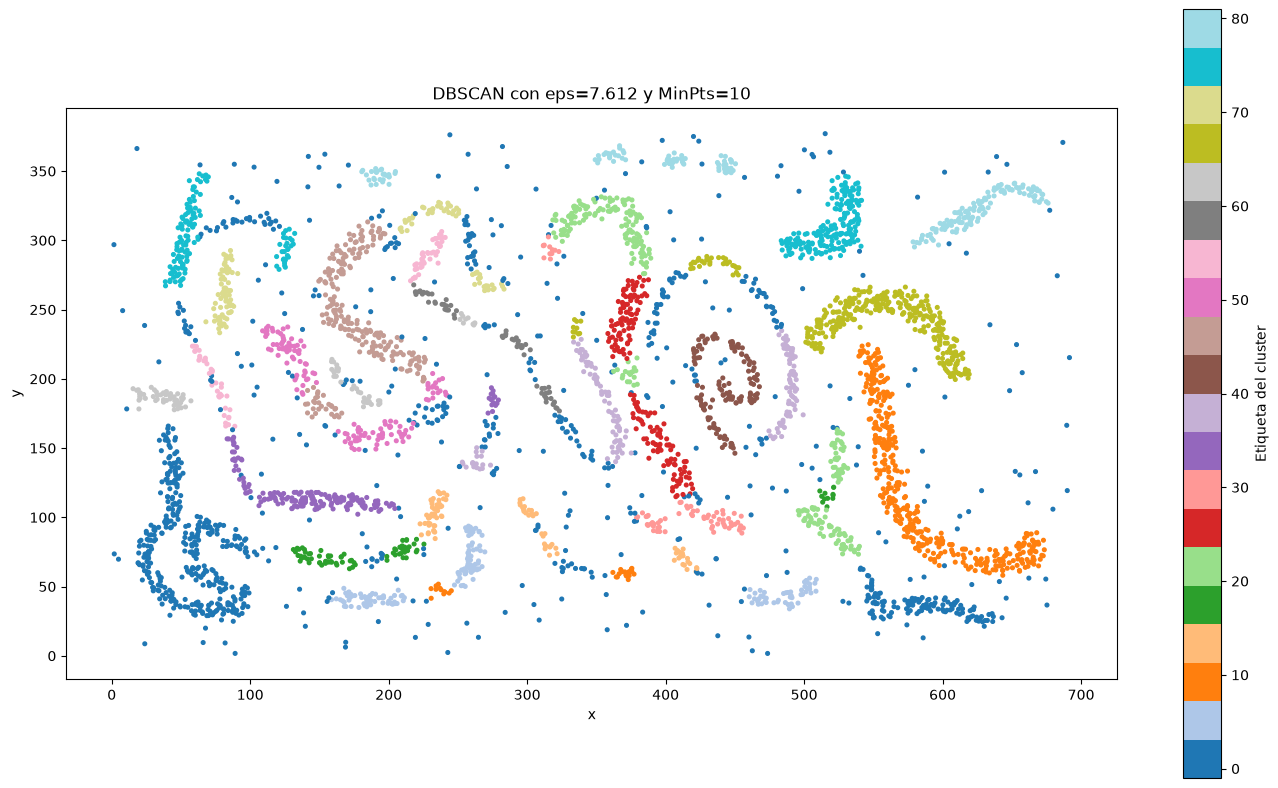

Número de clusters detectados: 82
Número de outliers (-1): 549
Número de regiones originales en la imagen: 40


In [9]:
# Ajuste final del modelo DBSCAN con los parámetros seleccionados.
model = DBSCAN(eps=best_eps, min_samples=best_min_pts)
labels_dbscan = model.fit_predict(X)

# Visualización del clustering final.
fig, ax = plt.subplots(figsize=(14, 8))
scatter = ax.scatter(X[:, 0], X[:, 1], c=labels_dbscan, cmap="tab20", s=7)
ax.set_title(f"DBSCAN con eps={best_eps:.3f} y MinPts={best_min_pts}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
plt.colorbar(scatter, ax=ax, label="Etiqueta del cluster")
plt.tight_layout()
plt.show()

n_clusters = len(np.unique(labels_dbscan[labels_dbscan != -1]))
print(f"Número de clusters detectados: {n_clusters}")
print(f"Número de outliers (-1): {(labels_dbscan == -1).sum()}")
print(f"Número de regiones originales en la imagen: {len(valid_regions)}")


In [5]:
# Evaluación de desempeño para clustering.
# Se usan dos métricas del módulo sklearn.metrics recomendadas para clustering
# no supervisado (ver "Clustering performance evaluation" en la documentación
# de scikit-learn), más una tercera de referencia:
#  - Silhouette Score: qué tan bien cada punto encaja en su propio clúster
#    frente a los demás (rango [-1, 1], más alto es mejor).
#  - Davies-Bouldin Index: relación entre dispersión intra-clúster y
#    separación inter-clúster (valores más bajos = clústeres más compactos
#    y mejor separados).
#  - Calinski-Harabasz Score: razón entre dispersión inter e intra-clúster
#    (más alto es mejor); se reporta como referencia adicional.
valid = labels_dbscan != -1
if valid.sum() >= 2 and len(np.unique(labels_dbscan[valid])) > 1:
    sil_score = silhouette_score(X[valid], labels_dbscan[valid])
    db_score = davies_bouldin_score(X[valid], labels_dbscan[valid])
    ch_score = calinski_harabasz_score(X[valid], labels_dbscan[valid])
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Davies-Bouldin Index: {db_score:.4f}")
    print(f"Calinski-Harabasz Score: {ch_score:.4f}")
else:
    print("No se puede evaluar con estas métricas porque solo existe un clúster único o casi no hay puntos válidos.")

# Para una interpretación más clara, también se reporta el porcentaje de puntos etiquetados como ruido.
noise_ratio = (labels_dbscan == -1).mean()
print(f"Proporción de outliers: {noise_ratio:.2%}")


Silhouette Score: 0.4575
Davies-Bouldin Index: 0.5124
Calinski-Harabasz Score: 9434.8857
Proporción de outliers: 13.14%


## Interpretación

- La imagen de referencia contiene varios grupos amorfos (82 regiones detectadas), por lo que es una buena base para generar un conjunto sintético 2D.
- El muestreo de puntos por región es proporcional al área de cada región (no un tope fijo), para mantener una densidad similar entre trazos largos y manchas compactas; esto es clave para que DBSCAN, que depende de la densidad local, no fragmente los trazos largos en muchos mini-clústeres.
- El análisis de k-distancia ayuda a localizar el punto de inflexión (codo) que sugiere un valor razonable de epsilon; la búsqueda de parámetros se centra alrededor de esa estimación en vez de un rango arbitrario.
- La búsqueda de (eps, MinPts) descarta configuraciones con muy pocos clústeres o con más de 35% de ruido, para evitar que la silueta favorezca mini-clústeres triviales a costa de mandar casi todos los puntos a ruido.
- En clustering no supervisado, la métrica más útil es la silueta, porque cuantifica cuán bien separados y compactos están los clústeres; el índice de Davies-Bouldin complementa el análisis (valores más bajos indican mejor separación).
- Los puntos marcados como -1 corresponden a outliers de DBSCAN y representan ruido en los datos.

Este enfoque permite evaluar no solo la calidad del agrupamiento, sino también la sensibilidad del modelo a la presencia de ruido y estructuras amorfas.